### Installing libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading csv file


In [24]:
data = pd.read_csv("housing.csv")

In [25]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Handling missing values

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [27]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [28]:
data.isnull().mean()*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In this we can apply CCA(Complete case analysis) 
Only 1% data is missing 

In [30]:
cols = [var for var in data.columns if data[var].isnull().mean() < 0.03 and data[var].isnull().mean() > 0]
cols

['total_bedrooms']

In [31]:
data[cols].sample(5)

,total_bedrooms
15564,642.0
18115,301.0
4760,601.0
2260,795.0
1845,516.0


 THIS IS THE DATA WHICH WILL REMAIN IF WE DELETED THE ROWS WITH MISSING VALUES

In [33]:
len(data[cols].dropna()) / len(data)

0.9899709302325581

In [35]:
new_data = data[cols].dropna()
data.shape, new_data.shape

((20640, 10), (20433, 1))

<Axes: >

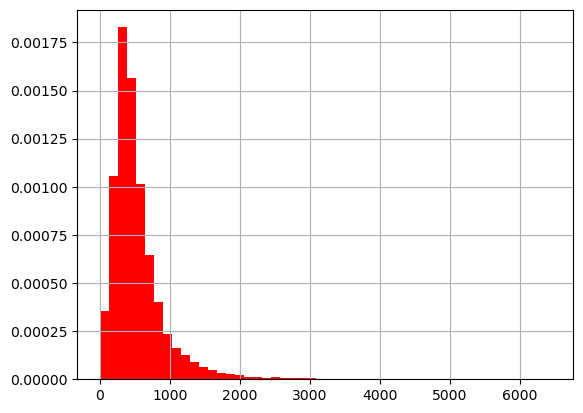

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
data['total_bedrooms'].hist(bins=50, ax=ax, density=True, color='red')

#New data (data after CCA)
new_data['total_bedrooms'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

AS GREEN AND RED DATA ARE FULLY OVERLAPPING MEANS THAT THERE IS NO LOSS OF INFORMATION OR DATA AFTER APPLYING CCA 
### CONCLUSION :  ACCORDING TO THE HISTOGRAM PLOT -> WE CAN APPLY CCA 

<Axes: ylabel='Density'>

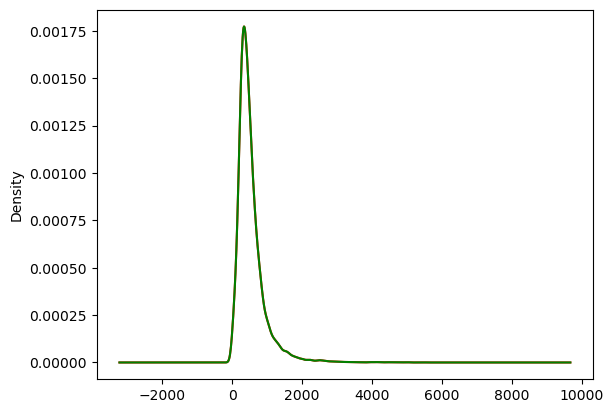

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)
#original data
data['total_bedrooms'].plot.density(color='red')

#after CCA
new_data['total_bedrooms'].plot.density(color='green')

AS GREEN AND RED ARE AGAIN FULLY OVERLAPPING MEANS WE CAN APPLY CCA
### CONCLUSION : DENSITY PLOT -> WE CAN APPLY CCA 

In [51]:
data.dropna(inplace=True)

## using CCA for handling missing values

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB
